## Marvel Movie Analysis

### Table of Contents

* [Goals](#Goals)
* [Setup](#Setup)
    * [Installing R packages](#Packages)
    * [Loading the Data](#Loading)
* [Data](#Data)
* [Data Inspection and Cleaning](#Inspect)
    * [Adjusting column names - Movies](#Columns_movies)
    * [Check for duplicates, nulls, and missing values - Movies](#duplicates_movies)
    * [Validate column data - Movies](#validity_movies)
    * [Adjusting column names - Reviews](#Columns_reviews)
    * [Check for duplicates, nulls, and missing values - Reviews](#duplicates_reviews)
    * [Validate column data - Reviews](#validity_reviews)
    * [Merge Reviews and Movies](#merge) 
    * [Initial observations](#initial_observations)
* [Exploratory Data Analysis](#exploratory_analysis)
    * [Averages](#average)
    * [Opening weekend](#opening_weekend)
    * [Budget](#budget)
    * [Profit](#profit)
    * [Distributor](#distributor)
    * [Ratings](#ratings)
* [Conclusion](#Conclusion)
    

### Setup <a class='anchor' id='Setup'></a>

#### Installing R Packages <a class='anchor' id='Packages'></a>

In [223]:
#install.packages("tidyverse")

In [89]:
library(ggplot2)
library(readr)
library(tidyr)
library(dplyr)
library(stringr)

### Loading the data <a class='anchor' id='Loading'></a>

In [90]:
movies <- read_csv('marvel.csv', locale=locale(encoding="latin1"))

Rows: 66 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (8): Title, Distributor, Release date US, Bud­get millions, Opening week...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [91]:
reviews <- read_csv('marvel_reviews.csv')

Rows: 67 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Film, Rotten Tomatoes, Metacritic, CinemaScore

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Data <a class='anchor' id='Data'></a>

This data was gathered from Kaggle. 

Additional information about the data set, including it's creator and column descriptions, can be found here: https://www.kaggle.com/datasets/minisam/marvel-movie-dataset?select=marvel_reviews.csv

### Data Inspection and Cleaning <a class='anchor' id='Inspect'></a>

#### Movies

In [92]:
head(movies)

Title,Distributor,Release date US,Bud­get millions,Opening weekend North America,North America,Other territories,Worldwide
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Howard the Duck,Universal Pictures,August 1 1986,$37,$5070136,$16295774,$21667000,$37962774
Blade,New Line Cinema,August 21 1998,$45,$17073856,$70087718,$61095812,$131183530
X-Men,20th Century Fox,July 14 2000,$75,$54471475,$157299717,$139039810,$296339527
Blade II,New Line Cinema,March 22 2002,$54,$32528016,$82348319,$72661713,$155010032
Spider-Man,Sony Pictures,May 3 2002,$139,$114844116,$403706375,$418002176,$821708551
Daredevil,20th Century Fox,February 14 2003,$78,$40310419,$102543518,$76636200,$179179718


#### Rename Movie Columns <a class='anchor' id='Columns_movies'></a>

In [93]:
movies <- movies %>%
    rename(title = 'Title', distributor = 'Distributor', release_date_us = 'Release date US', budget_mil = 'Bud­get millions', opening_weekend_na = 'Opening weekend North America', north_america = 'North America', other_territories = 'Other territories', worldwide = 'Worldwide')

In [94]:
head(movies)

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Howard the Duck,Universal Pictures,August 1 1986,$37,$5070136,$16295774,$21667000,$37962774
Blade,New Line Cinema,August 21 1998,$45,$17073856,$70087718,$61095812,$131183530
X-Men,20th Century Fox,July 14 2000,$75,$54471475,$157299717,$139039810,$296339527
Blade II,New Line Cinema,March 22 2002,$54,$32528016,$82348319,$72661713,$155010032
Spider-Man,Sony Pictures,May 3 2002,$139,$114844116,$403706375,$418002176,$821708551
Daredevil,20th Century Fox,February 14 2003,$78,$40310419,$102543518,$76636200,$179179718


In [95]:
nrow(movies)

[1] 66

#### Check for Duplicates, Nulls, and Missing Values - Movies <a class='anchor' id='duplicates_movies'></a>

In [96]:
#check for row duplicates
sum(duplicated(movies))

[1] 0

In [97]:
#any null values? 
sum(is.null(movies))

[1] 0

In [98]:
#any missing values?
sum(is.na(movies))

#identify what columns contain the missing values
sapply(movies, function(x) sum(is.na(x)))

[1] 0

title        distributor    release_date_us         budget_mil 
                 0                  0                  0                  0 
opening_weekend_na      north_america  other_territories          worldwide 
                 0                  0                  0                  0

#### Validate Movies Column Data <a class='anchor' id='validity_movies'></a>

In [99]:
str(movies)

spc_tbl_ [66 × 8] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ title             : chr [1:66] "Howard the Duck" "Blade" "X-Men" "Blade II" ...
 $ distributor       : chr [1:66] "Universal Pictures" "New Line Cinema" "20th Century Fox" "New Line Cinema" ...
 $ release_date_us   : chr [1:66] "August 1 1986" "August 21 1998" "July 14 2000" "March 22 2002" ...
 $ budget_mil        : chr [1:66] "$37" "$45" "$75" "$54" ...
 $ opening_weekend_na: chr [1:66] "$5070136" "$17073856" "$54471475" "$32528016" ...
 $ north_america     : chr [1:66] "$16295774" "$70087718" "$157299717" "$82348319" ...
 $ other_territories : chr [1:66] "$21667000" "$61095812" "$139039810" "$72661713" ...
 $ worldwide         : chr [1:66] "$37962774" "$131183530" "$296339527" "$155010032" ...
 - attr(*, "spec")=
  .. cols(
  ..   Title = col_character(),
  ..   Distributor = col_character(),
  ..   `Release date US` = col_character(),
  ..   `Bud­get millions` = col_character(),
  ..   `Opening weekend North America` = co

In [100]:
#total rows in df: 66
movies %>%
    summarize(n_distinct(title))

n_distinct(title)
<int>
65


In [101]:
#title
movies %>%
    group_by(title) %>%
    filter(n() >1)

#different movies, same title

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Fantastic Four,20th Century Fox,July 8 2005,$100,$56061504,$154696080,$175883639,$330579719
Fantastic Four,20th Century Fox,August 7 2015,$120,$25685737,$56117548,$111765333,$167882881


In [102]:
#distributor
table(movies$distributor)


                   20th Century Fox                20th Century Studios 
                                 17                                   1 
                            Average                  IMAX Entertainment 
                                  1                                   1 
                    Lionsgate Films                     New Line Cinema 
                                  2                                   3 
                 Paramount Pictures                       Sony Pictures 
                                  4                                  13 
                              Total                  Universal Pictures 
                                  1                                   3 
Walt Disney Studios Motion Pictures 
                                 20 

In [103]:
#20th Century Studios is the rebranded 20th Centry Fox after Disney acquisition

In [104]:
#remove Total and Average row
movies <- movies %>%
    filter(distributor != 'Total')
movies <- movies %>%
    filter(distributor != 'Average')

table(movies$distributor)


                   20th Century Fox                20th Century Studios 
                                 17                                   1 
                 IMAX Entertainment                     Lionsgate Films 
                                  1                                   2 
                    New Line Cinema                  Paramount Pictures 
                                  3                                   4 
                      Sony Pictures                  Universal Pictures 
                                 13                                   3 
Walt Disney Studios Motion Pictures 
                                 20 

In [105]:
#release date - should be no competing release dates

movies %>%
    group_by(release_date_us) %>%
    filter(n() >1)

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>


In [106]:
#remove $ from budget_mil and change data type
movies$budget_mil <- as.numeric(gsub('\\$', '', movies$budget_mil))

Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


In [107]:
movies %>%
    filter(is.na(budget_mil))

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Inhumans,IMAX Entertainment,September 1 2017,NA,$1500000,$1521787,$1330495,$2852282


In [108]:
#remove $ from opening_weekend_na and change data type
movies$opening_weekend_na <- as.numeric(gsub('\\$', '', movies$opening_weekend_na))

In [109]:
#remove $ from north_america and change data type
movies$north_america <- as.numeric(gsub('\\$', '', movies$north_america))

In [110]:
#remove $ from other_territories and change data type
movies$other_territories <- as.numeric(gsub('\\$', '', movies$other_territories))

In [111]:
#remove $ from worldwide and change data type
movies$worldwide <- as.numeric(gsub('\\$', '', movies$worldwide))

In [112]:
#convert budget_mil 
movies <- movies %>%
    mutate(budget_mil = budget_mil * 1000000)

In [113]:
head(movies)

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Howard the Duck,Universal Pictures,August 1 1986,3.70e+07,5070136,16295774,21667000,37962774
Blade,New Line Cinema,August 21 1998,4.50e+07,17073856,70087718,61095812,131183530
X-Men,20th Century Fox,July 14 2000,7.50e+07,54471475,157299717,139039810,296339527
Blade II,New Line Cinema,March 22 2002,5.40e+07,32528016,82348319,72661713,155010032
Spider-Man,Sony Pictures,May 3 2002,1.39e+08,114844116,403706375,418002176,821708551
Daredevil,20th Century Fox,February 14 2003,7.80e+07,40310419,102543518,76636200,179179718


In [114]:
str(movies)

tibble [64 × 8] (S3: tbl_df/tbl/data.frame)
 $ title             : chr [1:64] "Howard the Duck" "Blade" "X-Men" "Blade II" ...
 $ distributor       : chr [1:64] "Universal Pictures" "New Line Cinema" "20th Century Fox" "New Line Cinema" ...
 $ release_date_us   : chr [1:64] "August 1 1986" "August 21 1998" "July 14 2000" "March 22 2002" ...
 $ budget_mil        : num [1:64] 3.70e+07 4.50e+07 7.50e+07 5.40e+07 1.39e+08 7.80e+07 1.10e+08 1.37e+08 3.30e+07 2.00e+08 ...
 $ opening_weekend_na: num [1:64] 5.07e+06 1.71e+07 5.45e+07 3.25e+07 1.15e+08 ...
 $ north_america     : num [1:64] 1.63e+07 7.01e+07 1.57e+08 8.23e+07 4.04e+08 ...
 $ other_territories : num [1:64] 2.17e+07 6.11e+07 1.39e+08 7.27e+07 4.18e+08 ...
 $ worldwide         : num [1:64] 3.80e+07 1.31e+08 2.96e+08 1.55e+08 8.22e+08 ...


#### Reviews

In [115]:
head(reviews)

Film,Rotten Tomatoes,Metacritic,CinemaScore
<chr>,<chr>,<chr>,<chr>
Howard the Duck,14% (81 reviews)[24],28 (21 reviews)[25],B-[26]
The Punisher (1989),28% (18 reviews)[27],63 (4 reviews)[28],NA
Captain America (1990),13% (16 reviews)[29],NA,NA
The Fantastic Four (1994),30% (10 reviews)[30],NA,NA
Blade,57% (106 reviews)[31],47 (25 reviews)[32],A-[26]
X-Men,82% (175 reviews)[33],64 (33 reviews)[34],A-[26]


In [116]:
nrow(reviews)

[1] 67

#### Rename Review Columns <a class='anchor' id='Columns_reviews'></a>

In [117]:
reviews <- reviews %>%
    rename(film = 'Film', rotten_tomatoes = 'Rotten Tomatoes', metacritic = 'Metacritic', cinema_score = 'CinemaScore')
head(reviews)

film,rotten_tomatoes,metacritic,cinema_score
<chr>,<chr>,<chr>,<chr>
Howard the Duck,14% (81 reviews)[24],28 (21 reviews)[25],B-[26]
The Punisher (1989),28% (18 reviews)[27],63 (4 reviews)[28],NA
Captain America (1990),13% (16 reviews)[29],NA,NA
The Fantastic Four (1994),30% (10 reviews)[30],NA,NA
Blade,57% (106 reviews)[31],47 (25 reviews)[32],A-[26]
X-Men,82% (175 reviews)[33],64 (33 reviews)[34],A-[26]


#### Check for Duplicates, Nulls, and Missing Values - Reivews <a class='anchor' id='duplicates_reviews'></a>

In [118]:
#check for row duplicates
sum(duplicated(reviews))

[1] 0

In [119]:
#any null values? 
sum(is.null(reviews))

[1] 0

In [120]:
#any missing values?
sum(is.na(reviews))

#identify what columns contain the missing values
reviews %>%
    filter(is.na(cinema_score) | is.na(rotten_tomatoes) | is.na(metacritic))

[1] 8

film,rotten_tomatoes,metacritic,cinema_score
<chr>,<chr>,<chr>,<chr>
The Punisher (1989),28% (18 reviews)[27],63 (4 reviews)[28],NA
Captain America (1990),13% (16 reviews)[29],NA,NA
The Fantastic Four (1994),30% (10 reviews)[30],NA,NA
Man-Thing,17% (6 reviews)[53],NA,NA
The New Mutants,36% (130 reviews)[144],43 (20 reviews)[145],NA


#### Validate Reviews Column Data <a class='anchor' id='validity_reviews'></a>

In [121]:
str(reviews)

spc_tbl_ [67 × 4] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ film           : chr [1:67] "Howard the Duck" "The Punisher (1989)" "Captain America (1990)" "The Fantastic Four (1994)" ...
 $ rotten_tomatoes: chr [1:67] "14% (81 reviews)[24]" "28% (18 reviews)[27]" "13% (16 reviews)[29]" "30% (10 reviews)[30]" ...
 $ metacritic     : chr [1:67] "28 (21 reviews)[25]" "63 (4 reviews)[28]" NA NA ...
 $ cinema_score   : chr [1:67] "B-[26]" NA NA NA ...
 - attr(*, "spec")=
  .. cols(
  ..   Film = col_character(),
  ..   `Rotten Tomatoes` = col_character(),
  ..   Metacritic = col_character(),
  ..   CinemaScore = col_character()
  .. )
 - attr(*, "problems")=<externalptr> 


In [122]:
#film - ensure there are no duplicate titles

reviews %>%
    group_by(film) %>%
    filter(n() >1)

film,rotten_tomatoes,metacritic,cinema_score
<chr>,<chr>,<chr>,<chr>


In [123]:
#check film titles for character translation errors
reviews %>%
    arrange((film))

reviews %>% 
    arrange(desc(film))

film,rotten_tomatoes,metacritic,cinema_score
<chr>,<chr>,<chr>,<chr>
Ant-Man,83% (336 reviews)[104],64 (44 reviews)[105],A[26]
Ant-Man and the Wasp,87% (438 reviews)[130],70 (54 reviews)[131],A-[26]
Avengers: Age of Ultron,76% (375 reviews)[102],66 (49 reviews)[103],A[26]
Avengers: Endgame,94% (547 reviews)[138],78 (57 reviews)[139],A+[26]
Avengers: Infinity War,85% (485 reviews)[126],68 (53 reviews)[127],A[26]
Big Hero 6,90% (227 reviews)[100],74 (39 reviews)[101],A[26]
Black Panther,96% (525 reviews)[124],88 (55 reviews)[125],A+[26]
Black Widow,79% (438 reviews)[146],67 (57 reviews)[147],A-[26]
Blade,57% (106 reviews)[31],47 (25 reviews)[32],A-[26]


film,rotten_tomatoes,metacritic,cinema_score
<chr>,<chr>,<chr>,<chr>
X2,85% (247 reviews)[41],68 (37 reviews)[42],A[26]
X-Men: The Last Stand,57% (240 reviews)[56],58 (38 reviews)[57],A-[26]
X-Men: First Class,86% (298 reviews)[76],65 (38 reviews)[77],B+[26]
X-Men: Days of Future Past,90% (330 reviews)[96],75 (44 reviews)[97],A[26]
X-Men: Apocalypse,47% (345 reviews)[112],52 (48 reviews)[113],A-[26]
X-Men Origins: Wolverine,37% (263 reviews)[70],40 (39 reviews)[71],B+[26]
X-Men,82% (175 reviews)[33],64 (33 reviews)[34],A-[26]
Venom: Let There Be Carnage,58% (262 reviews)[150],49 (48 reviews)[151],B+[26]
Venom,30% (359 reviews)[132],35 (46 reviews)[133],B+[26]


In [124]:
#rotten_tomatoes (rt) separate percentages and number of reviews
reviews <- reviews %>%
    separate(col = rotten_tomatoes, into=c('rt_percentage', 'rt_review_amounts', 'rt_extra'), sep = ' ')

#remove rt_extra
reviews <- reviews %>%
    select(-rt_extra)

In [125]:
#remove extra symbols from rt_percentage and change to numeric data type
reviews$rt_percentage <- as.numeric(gsub('\\%', '', reviews$rt_percentage))

In [126]:
#remove extra symbols from rt_review_amounts and change to numeric data type
reviews$rt_review_amounts <- as.numeric(gsub('\\(', '', reviews$rt_review_amounts))

In [127]:
#check rt_percentage (should be between 0 and 100)
reviews %>%
    filter(rt_percentage > 100 | rt_percentage < 0)

film,rt_percentage,rt_review_amounts,metacritic,cinema_score
<chr>,<dbl>,<dbl>,<chr>,<chr>


In [128]:
#metacritic separate percentages and number of reviews
reviews <- reviews %>%
    separate(col = metacritic, into=c('metacritic_score', 'metacritic_review_amounts', 'm_extra'), sep = ' ')

#remove m_extra
reviews <- reviews %>%
    select(-m_extra)

In [129]:
#remove extra symbols from metacritic_review_amounts and change to numeric data type
reviews$metacritic_review_amounts <- as.numeric(gsub('\\(', '', reviews$metacritic_review_amounts))

In [130]:
#change metacritic_score to numeric data type
reviews$metacritic_score <- as.numeric(reviews$metacritic_score)

In [131]:
#check metacritic_score values (should be between 0 and 100)
reviews %>%
    filter(metacritic_score > 100 | metacritic_score < 0)

film,rt_percentage,rt_review_amounts,metacritic_score,metacritic_review_amounts,cinema_score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


In [132]:
#remove cinema_score reference brackets
reviews <- reviews %>%
    separate(col = cinema_score, into=c('cinema_score', 'c_extra'), sep = '\\[')

#remove c_extra
reviews <- reviews %>%
    select(-c_extra)

In [133]:
#check cinema_score values (should be a letter grade)
table(reviews$cinema_score)


 A A- A+  B B- B+ C- C+ 
21 14  5  6  6  8  1  1 

#### Merge Reviews and Movies <a class='anchor' id='merge'></a>

In [134]:
#address duplicate Fantastic Four titles in movies
#Fantastic Four films in movies
grep('Fantastic Four', movies$title, value = TRUE)

#check release date in movies
movies %>%
    group_by(title) %>%
    filter(n() > 1)

[1] "Fantastic Four"                           
[2] "Fantastic Four: Rise of the Silver Surfer"
[3] "Fantastic Four"

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fantastic Four,20th Century Fox,July 8 2005,1.0e+08,56061504,154696080,175883639,330579719
Fantastic Four,20th Century Fox,August 7 2015,1.2e+08,25685737,56117548,111765333,167882881


In [135]:
#Fantastic Four films in reviews
grep('Fantastic Four', reviews$film, value = TRUE)

[1] "The Fantastic Four (1994)"                
[2] "Fantastic Four (2005)"                    
[3] "Fantastic Four: Rise of the Silver Surfer"
[4] "Fantastic Four (2015)"

In [136]:
#update Fantastic Four films with release year in movies df
movies$title[movies$release_date_us == 'July 8 2005'] <- 'Fantastic Four (2005)'
movies$title[movies$release_date_us == 'August 7 2015'] <- 'Fantastic Four (2015)'

In [137]:
#create title vectors for movies and reviews
movies_title_list = c(movies$title)
reviews_title_list = c(reviews$film)

In [138]:
#identify what titles movies has but reviews doesn't 
setdiff(movies_title_list, reviews_title_list)

#identify setdiff differences in reviews
grep('Punisher', reviews$film, value = TRUE)

#check release date in movies 
movies %>% 
    filter(title == 'The Punisher')

[1] "The Punisher" "Inhumans"

[1] "The Punisher (1989)" "The Punisher (2004)" "Punisher: War Zone"

title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
The Punisher,Lionsgate Films,April 16 2004,3.3e+07,13834527,33810189,20889916,54700105


In [139]:
#update Punisher title in movies to match the 2004 title in reviews
movies$title[movies$release_date_us == 'April 16 2004'] <- 'The Punisher (2004)'

In [140]:
#check to see if reviews has Inhumans
grep('Inhumans', reviews$film, value = TRUE)

#movies has Inhumans but reviews does not

character(0)

In [141]:
#identify what titles reviews has but movies doesn't 
setdiff(reviews_title_list, movies_title_list)

[1] "The Punisher (1989)"       "Captain America (1990)"   
[3] "The Fantastic Four (1994)" "The Punisher (2004)"      
[5] "Man-Thing"

In [142]:
#double check that Captain Amercia (1990) will not conflict with more recent Captain America movies
grep('Captain America', reviews$film, value = TRUE)

[1] "Captain America (1990)"              "Captain America: The First Avenger" 
[3] "Captain America: The Winter Soldier" "Captain America: Civil War"

In [143]:
#check film titles between reviews and movies to prepare for merge
reviews_title_list <- c(reviews$film)
movies_title_list <- c(movies$title)

print('Number of titles in reviews df:')
length(reviews_title_list)

print('Number of titles in movies df:')
length(movies_title_list)

print('Number of corresponding titles in both movies and reviews:')
length(intersect(reviews_title_list, movies_title_list))

[1] "Number of titles in reviews df:"


[1] 67

[1] "Number of titles in movies df:"


[1] 64

[1] "Number of corresponding titles in both movies and reviews:"


[1] 63

In [144]:
#rename film column in reviews to prepare for left join
reviews <- reviews %>%
    rename(title = 'film')

In [145]:
#left join movies and reviews based off of film title
movies_reviews <- movies %>%
    left_join(reviews)

head(movies_reviews)

Joining with `by = join_by(title)`


title,distributor,release_date_us,budget_mil,opening_weekend_na,north_america,other_territories,worldwide,rt_percentage,rt_review_amounts,metacritic_score,metacritic_review_amounts,cinema_score
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Howard the Duck,Universal Pictures,August 1 1986,3.70e+07,5070136,16295774,21667000,37962774,14,81,28,21,B-
Blade,New Line Cinema,August 21 1998,4.50e+07,17073856,70087718,61095812,131183530,57,106,47,25,A-
X-Men,20th Century Fox,July 14 2000,7.50e+07,54471475,157299717,139039810,296339527,82,175,64,33,A-
Blade II,New Line Cinema,March 22 2002,5.40e+07,32528016,82348319,72661713,155010032,57,151,52,28,B+
Spider-Man,Sony Pictures,May 3 2002,1.39e+08,114844116,403706375,418002176,821708551,90,244,73,38,A-
Daredevil,20th Century Fox,February 14 2003,7.80e+07,40310419,102543518,76636200,179179718,44,229,42,35,B


#### Initial Observations <a class='anchor' id='initial_observations'></a>

* Which distributors have been the most successful?
* Which distributor has had the best/worse performing movies?
* Do ratings correlate with revenue?
* Does a movie's budget correlate with its box office success?
* What were the peak years for marvel movies? 

### Exploratory Data Analysis <a class='anchor' id='exploratory_analysis'></a>

#### Averages <a class='anchor' id='averages'></a>

In [146]:
#create release_year column
movies_reviews$release_year <- str_sub(movies_reviews$release_date_us, -4, -1) 

In [147]:
#df timeline
max(movies_reviews$release_year)
min(movies_reviews$release_year)

[1] "2021"

[1] "1986"

In [148]:
#average earnings
domestic_opening_average <- round(mean(movies_reviews$opening_weekend_na), digits = 2)
print(paste('The average marvel movie domestic opening weekend earnings between 1986 and 2021 is', domestic_opening_average))

domestic_total_earnings_average <- round(mean(movies_reviews$north_america), digits = 2)
print(paste('The average marvel movie domestic total earnings between 1986 and 2021 is', domestic_total_earnings_average))

international_total_earnings_average <- round(mean(movies_reviews$other_territories), digits = 2)
print(paste('The average marvel movie international total earnings between 1986 and 2021 is', international_total_earnings_average))

worldwide_total_earnings_average <- round(mean(movies_reviews$worldwide), digits = 2)
print(paste('The average marvel movie worldwide total earnings between 1986 and 2021 is',worldwide_total_earnings_average))


[1] "The average marvel movie domestic opening weekend earnings between 1986 and 2021 is 90148236.16"
[1] "The average marvel movie domestic total earnings between 1986 and 2021 is 247027107.38"
[1] "The average marvel movie international total earnings between 1986 and 2021 is 382003334.34"
[1] "The average marvel movie worldwide total earnings between 1986 and 2021 is 629054379.92"


In [149]:
#average budget
average_budget_data <- movies_reviews %>%
    na.omit(budget_mil)

average_budget <- round(mean(average_budget_data$budget_mil), digits = 2)
print(paste('The average marvel movie budget from 1986 to 2021 is', average_budget, 'million'))

[1] "The average marvel movie budget from 1986 to 2021 is 151854838.71 million"


#### Opening Weekend Analysis <a class='anchor' id='opening_weekend'></a>

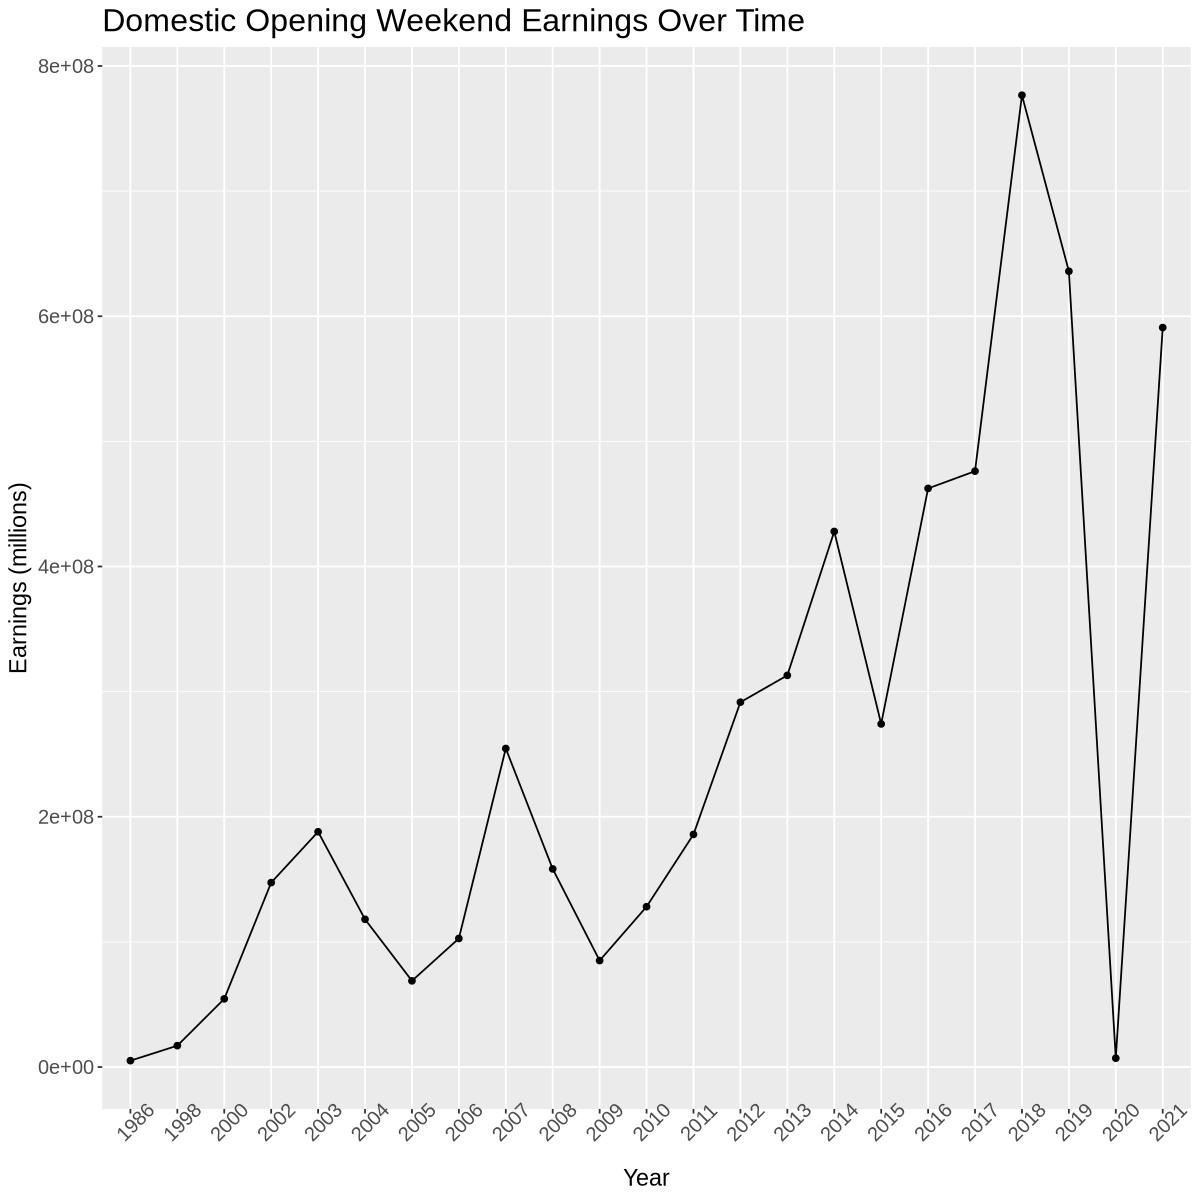

In [150]:
#plot domestic opening weekend earnings over time

d_opening_weekend_per_year <- movies_reviews %>%
    group_by(release_year) %>%
    summarize(opening_weekend_total = sum(opening_weekend_na))

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(data = d_opening_weekend_per_year, aes(x = release_year, y = opening_weekend_total)) + 
    geom_point() +
    geom_line(aes(group = 1)) + 
    theme(axis.text.x = element_text(angle = 45, size = 12), axis.text.y = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    coord_cartesian(ylim = c(min(d_opening_weekend_per_year$opening_weekend_total), max(d_opening_weekend_per_year$opening_weekend_total))) +
    labs(title = 'Domestic Opening Weekend Earnings Over Time', x = 'Year', y = 'Earnings (millions)')

In [151]:
#top 5 opening weekend movies
top_5_openings <- movies_reviews %>%
    arrange(desc(opening_weekend_na)) %>%
    select(title, distributor, release_year, opening_weekend_na)

head(top_5_openings, 5)

title,distributor,release_year,opening_weekend_na
<chr>,<chr>,<chr>,<dbl>
Avengers: Endgame,Walt Disney Studios Motion Pictures,2019,357115007
Spider-Man: No Way Home,Sony Pictures,2021,260138569
Avengers: Infinity War,Walt Disney Studios Motion Pictures,2018,257698183
The Avengers,Walt Disney Studios Motion Pictures,2012,207438708
Black Panther,Walt Disney Studios Motion Pictures,2018,202003951


In [152]:
#bototm 5 opening weekend movies
bottom_5_openings <- movies_reviews %>%
    arrange((opening_weekend_na)) %>%
    select(title, distributor, release_year, opening_weekend_na)

head(bottom_5_openings, 5)

title,distributor,release_year,opening_weekend_na
<chr>,<chr>,<chr>,<dbl>
Inhumans,IMAX Entertainment,2017,1500000
Punisher: War Zone,Lionsgate Films,2008,4271451
Howard the Duck,Universal Pictures,1986,5070136
The New Mutants,20th Century Studios,2020,7037017
Elektra,20th Century Fox,2005,12804793


In [153]:
#do any marvel movies perform better during their opening weekend vs their entire domestic run? 
#create column calculating difference between opening weekend and domestic revenue
opening_vs_run_data <- movies_reviews %>%
    mutate(opening_from_domestic = north_america - opening_weekend_na) %>%
    select(title, opening_weekend_na, north_america, opening_from_domestic)

opening_vs_run_data$comparison <- ifelse(opening_vs_run_data$opening_weekend_na > opening_vs_run_data$opening_from_domestic, TRUE, FALSE)

#analyze results
table(opening_vs_run_data$comparison)
opening_vs_run_data %>%
    filter(comparison == TRUE)


FALSE  TRUE 
   60     4 

title,opening_weekend_na,north_america,opening_from_domestic,comparison
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
Elektra,12804793,24409722,11604929,TRUE
Punisher: War Zone,4271451,8050977,3779526,TRUE
Inhumans,1500000,1521787,21787,TRUE
Eternals,85021497,164870234,79848737,TRUE


#### Budget Analysis <a class='anchor' id='budget'></a>

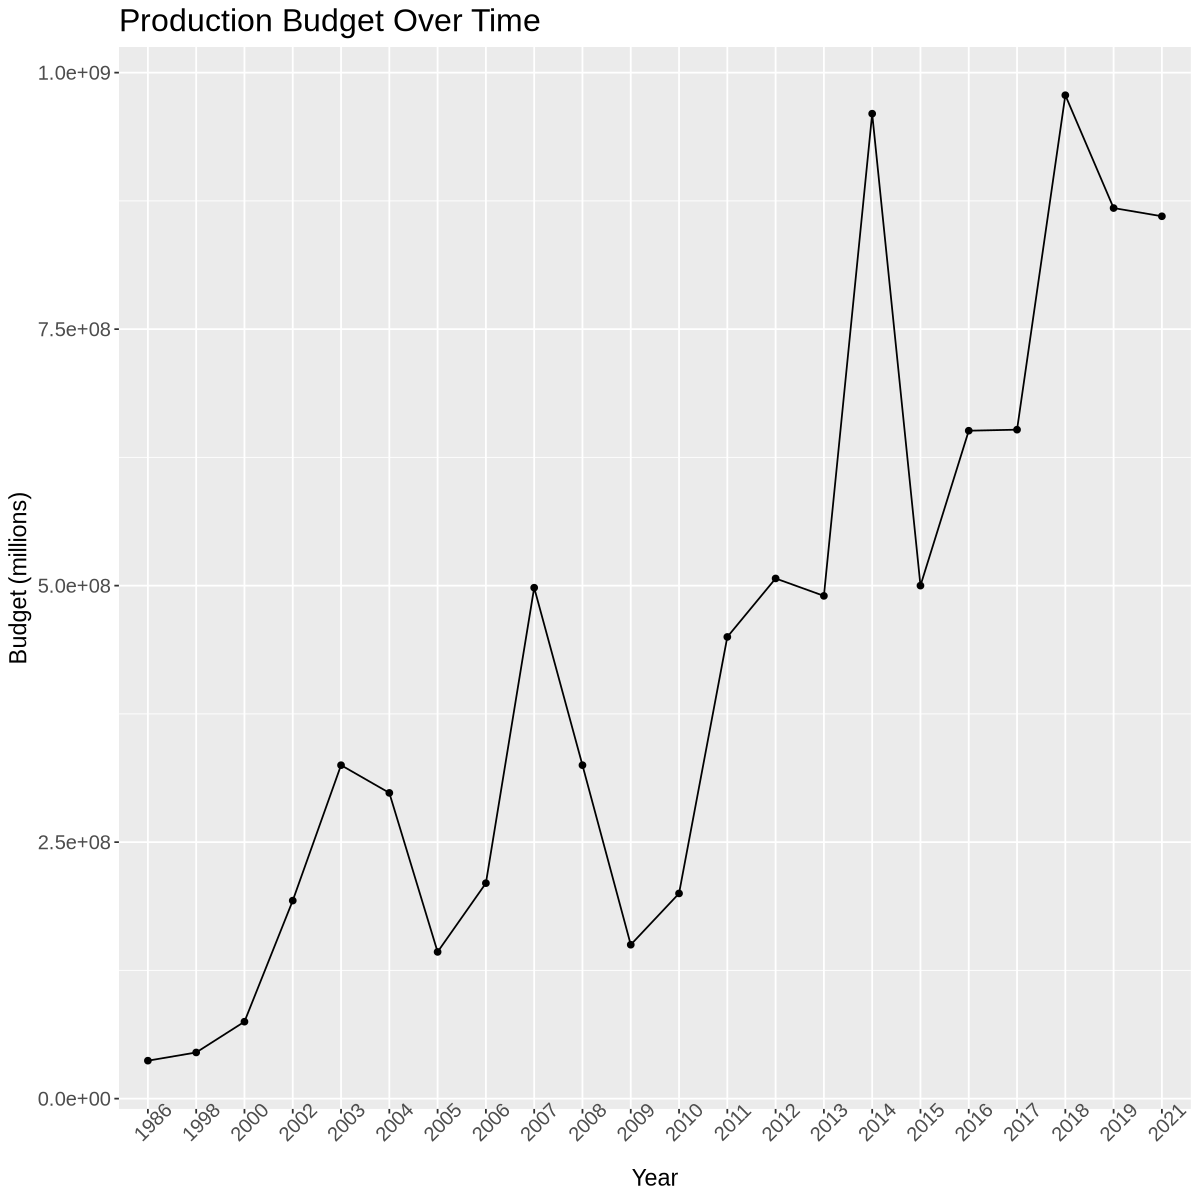

In [154]:
#plot budget over time
budget_per_year <- movies_reviews %>%
    group_by(release_year) %>%
    na.omit(budget_mil) %>%
    summarize(budget_total = sum(budget_mil))

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(data = budget_per_year, aes(x = release_year, y = budget_total)) + 
    geom_point() +
    geom_line(aes(group = 1)) + 
    theme(axis.text.x = element_text(angle = 45, size = 12), axis.text.y = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16) ) +
    coord_cartesian(ylim = c(min(budget_per_year$budget_total), max(budget_per_year$budget_total))) +
    labs(title = 'Production Budget Over Time', x = 'Year', y = 'Budget (millions)')

In [155]:
#top 5 highest budgets
top_5_budgets <- movies_reviews %>%
    arrange(desc(budget_mil)) %>%
    select(title, distributor, release_year, budget_mil)

head(top_5_budgets, 5)

title,distributor,release_year,budget_mil
<chr>,<chr>,<chr>,<dbl>
Avengers: Endgame,Walt Disney Studios Motion Pictures,2019,3.56e+08
Avengers: Infinity War,Walt Disney Studios Motion Pictures,2018,3.16e+08
Spider-Man 3,Sony Pictures,2007,2.58e+08
The Amazing Spider-Man 2,Sony Pictures,2014,2.55e+08
Avengers: Age of Ultron,Walt Disney Studios Motion Pictures,2015,2.50e+08


In [156]:
#top 5 lowest budgets
bottom_5_budgets <- movies_reviews %>%
    arrange((budget_mil)) %>%
    select(title, distributor, release_year, budget_mil)

head(bottom_5_budgets, 5)

title,distributor,release_year,budget_mil
<chr>,<chr>,<chr>,<dbl>
The Punisher (2004),Lionsgate Films,2004,3.3e+07
Punisher: War Zone,Lionsgate Films,2008,3.5e+07
Howard the Duck,Universal Pictures,1986,3.7e+07
Elektra,20th Century Fox,2005,4.3e+07
Blade,New Line Cinema,1998,4.5e+07


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'



	Pearson's product-moment correlation

data:  budget_worldwide$budget_mil and budget_worldwide$worldwide
t = 8.9732, df = 60, p-value = 1.095e-12
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6254616 0.8466655
sample estimates:
      cor 
0.7569748 


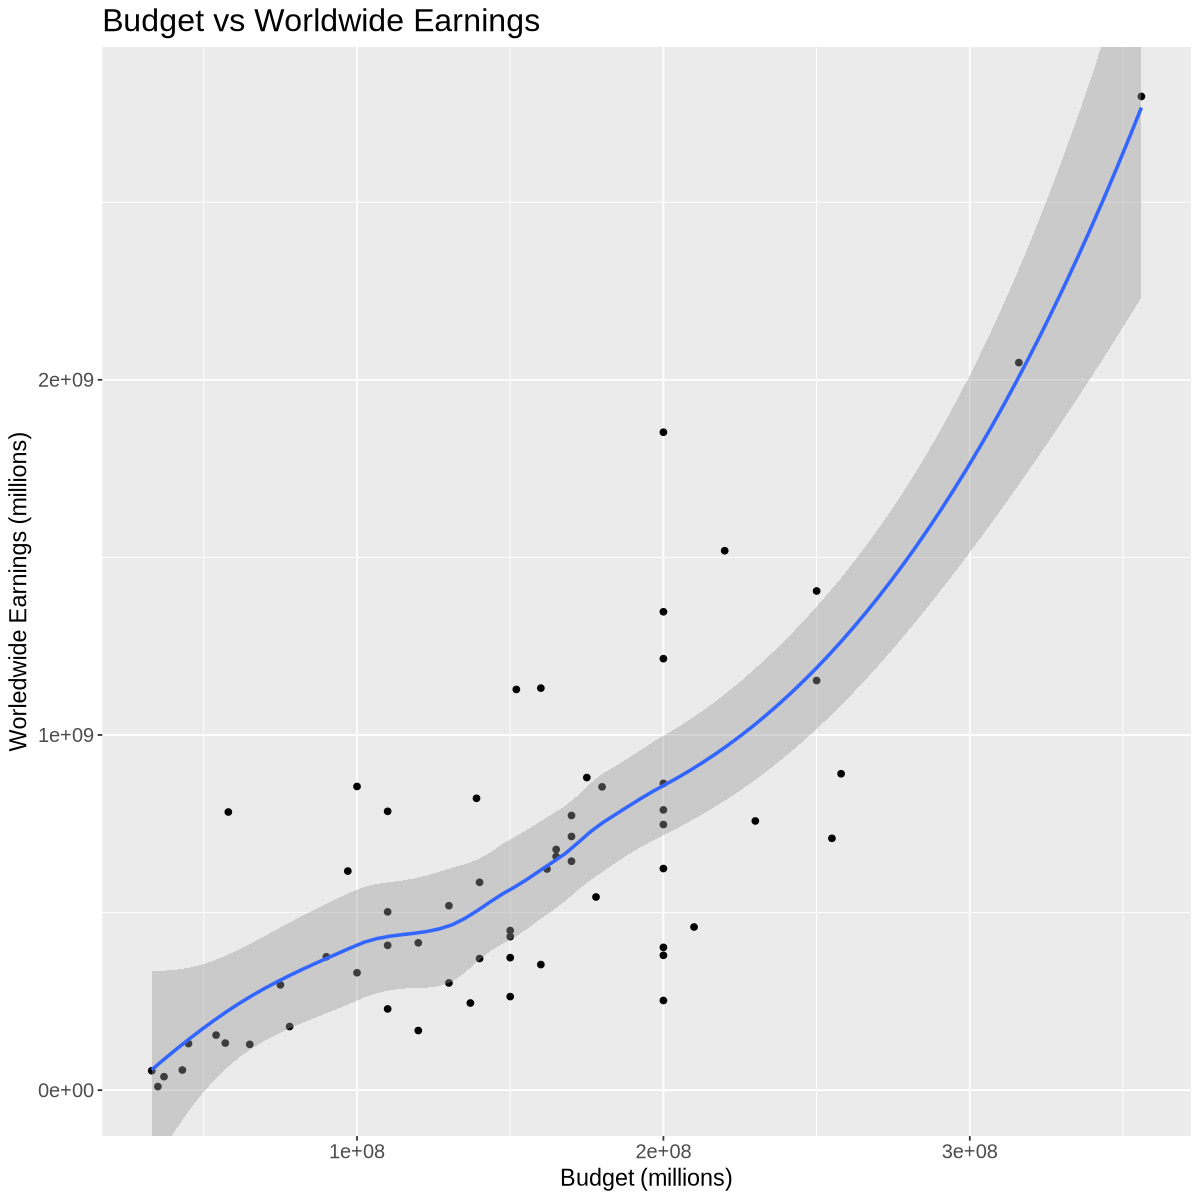

In [157]:
#does budget correlate with box office revenue? 
budget_worldwide <- movies_reviews %>%
    na.omit(budget_mil)

ggplot(data = budget_worldwide, aes(x = budget_mil, y = worldwide)) + 
    geom_point() +
    geom_smooth() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    coord_cartesian(ylim = c(min(budget_worldwide$worldwide), max(budget_worldwide$worldwide))) +
    labs(title = 'Budget vs Worldwide Earnings', x = 'Budget (millions)', y = 'Worledwide Earnings (millions)')

#correlation test
cor.test(budget_worldwide$budget_mil, budget_worldwide$worldwide)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'



	Pearson's product-moment correlation

data:  budget_total_profit$budget_mil and budget_total_profit$profit
t = 7.3922, df = 60, p-value = 5.351e-10
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5324406 0.8018871
sample estimates:
      cor 
0.6903954 


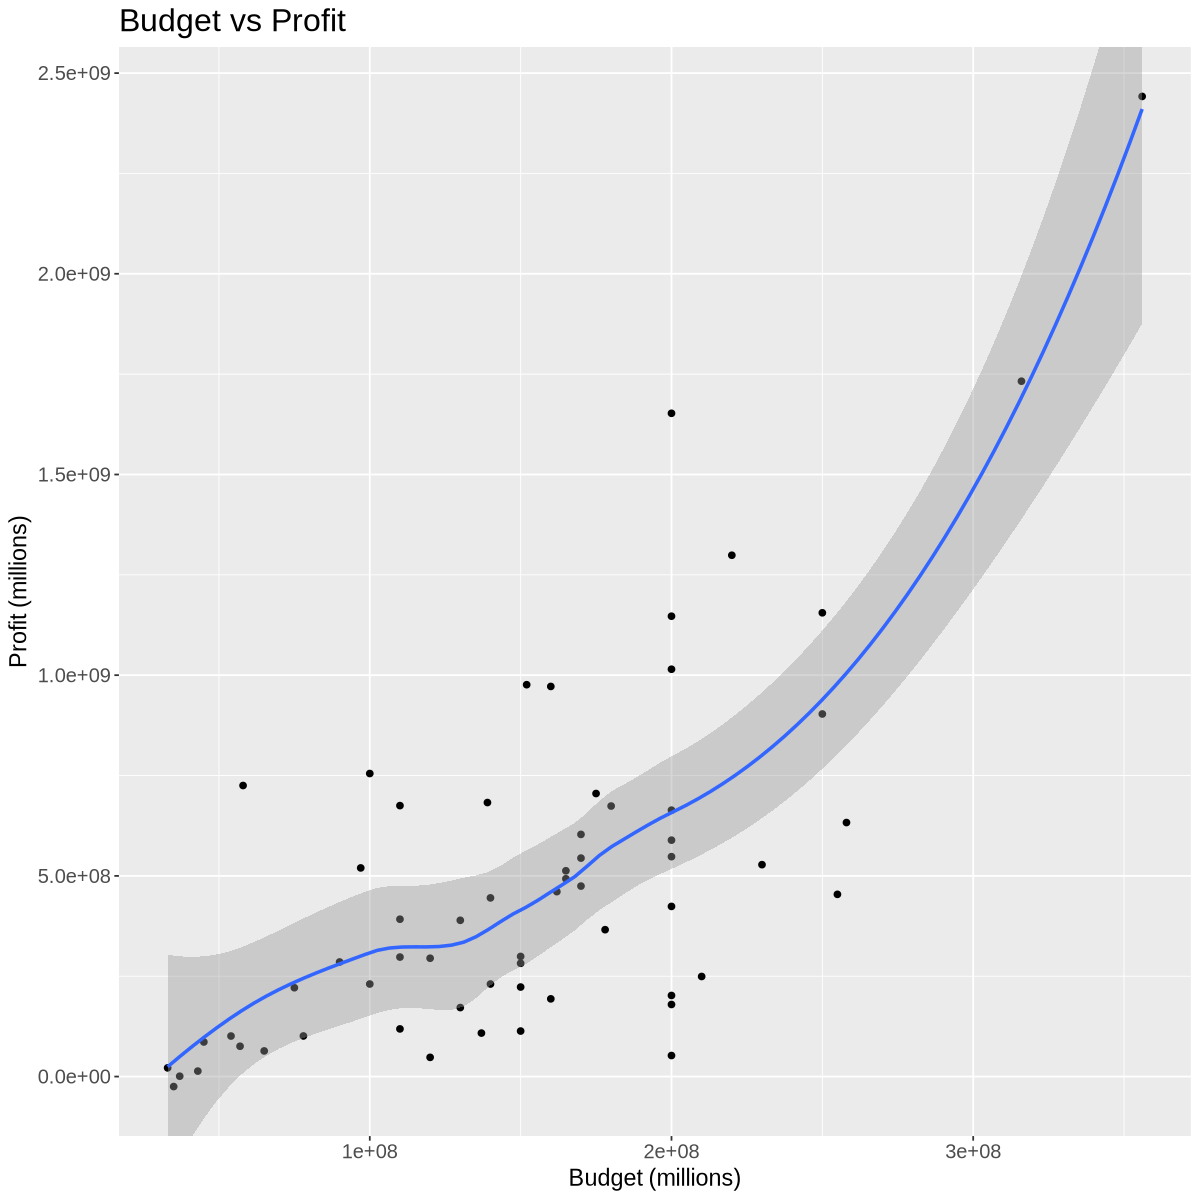

In [158]:
#does budget correlate with profit? 
#create profit column
movies_reviews <- movies_reviews %>%
    mutate(profit = worldwide - budget_mil) 

#omit budget NAs
budget_total_profit <- movies_reviews %>%
    na.omit(budget_mil)

#plot profits vs budget
ggplot(data = budget_total_profit, aes(x = budget_mil, y = profit)) + 
    geom_point() +
    geom_smooth() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    coord_cartesian(ylim = c(min(budget_total_profit$profit), max(budget_total_profit$profit))) +
    labs(title = 'Budget vs Profit', x = 'Budget (millions)', y = 'Profit (millions)')

#correlation test
cor.test(budget_total_profit$budget_mil, budget_total_profit$profit)

#### Profit <a class='anchor' id='profit'></a>

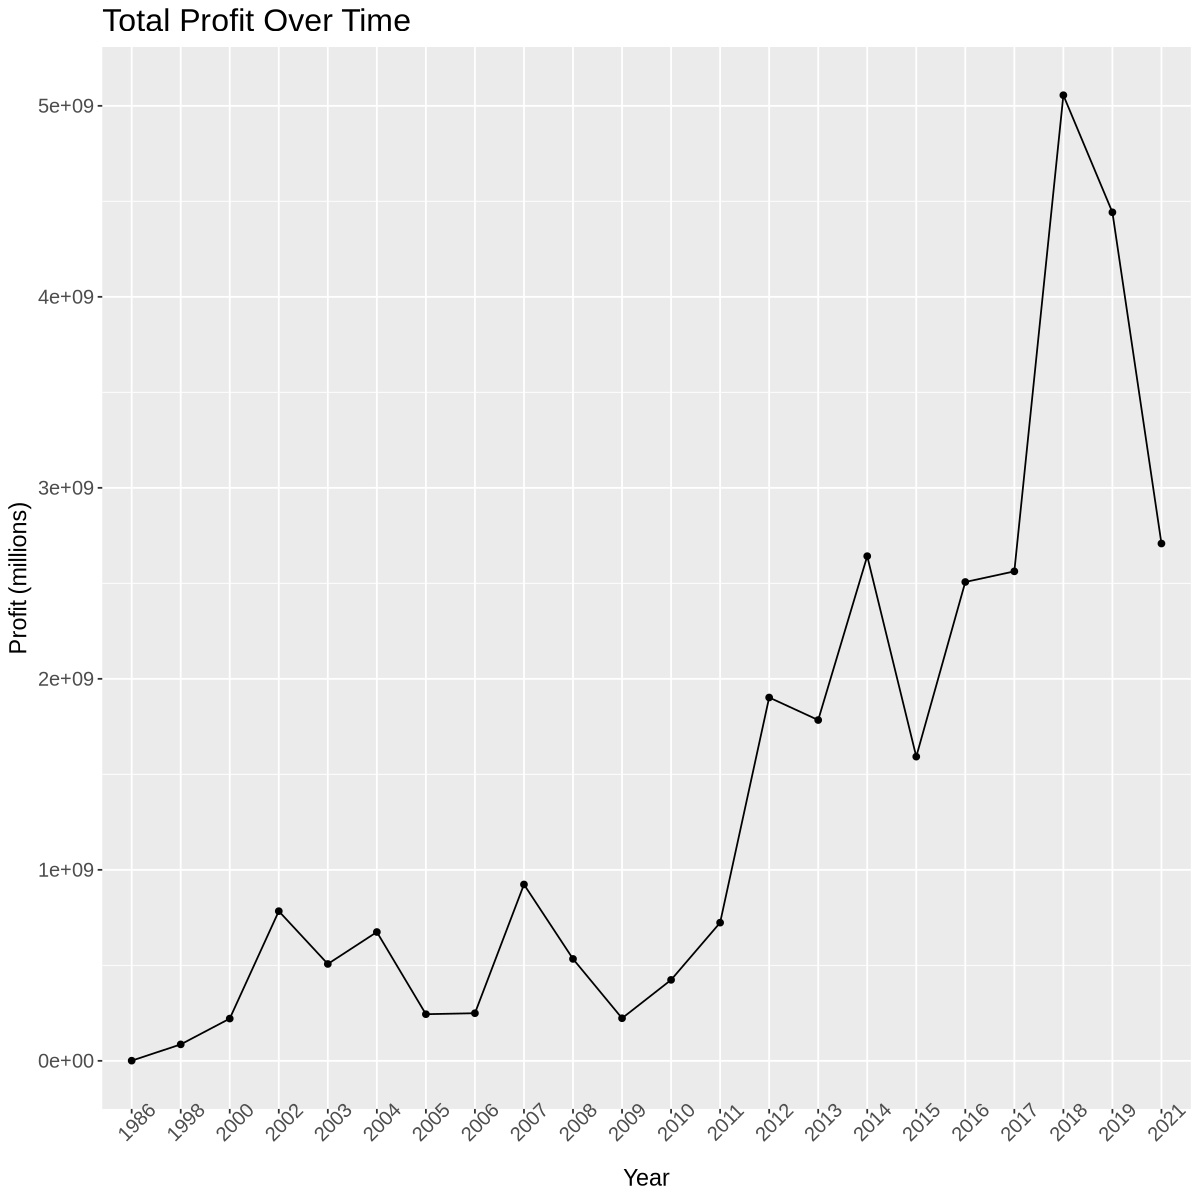

In [159]:
#plot total profit over time
profit_per_year <- movies_reviews %>%
    group_by(release_year) %>%
    na.omit(budget_mil) %>%
    summarize(total_profit = sum(profit))

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(data = profit_per_year, aes(x = release_year, y = total_profit)) + 
    geom_point() +
    geom_line(aes(group = 1)) + 
    theme(axis.text.x = element_text(angle = 45)) +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    coord_cartesian(ylim = c(min(profit_per_year$total_profit), max(profit_per_year$total_profit))) +
    labs(title = 'Total Profit Over Time', x = 'Year', y = 'Profit (millions)')

In [160]:
#top 5 most profitable movies
top_5_profit <- movies_reviews %>%
    arrange(desc(profit)) %>%
    na.omit(budget_mil) %>%
    select(title, distributor, release_year, profit)

head(top_5_profit, 5)

title,distributor,release_year,profit
<chr>,<chr>,<chr>,<dbl>
Avengers: Endgame,Walt Disney Studios Motion Pictures,2019,2441800564
Avengers: Infinity War,Walt Disney Studios Motion Pictures,2018,1732359754
Spider-Man: No Way Home,Sony Pictures,2021,1652418859
The Avengers,Walt Disney Studios Motion Pictures,2012,1298812988
Avengers: Age of Ultron,Walt Disney Studios Motion Pictures,2015,1155403694


In [161]:
#bottom 5 least profitable movies
bottom_5_profit <- movies_reviews %>%
    arrange(profit) %>%
    na.omit(budget_mil) %>%
    select(title, distributor, release_year, profit)

head(bottom_5_profit, 5)

title,distributor,release_year,profit
<chr>,<chr>,<chr>,<dbl>
Punisher: War Zone,Lionsgate Films,2008,-24899964
Howard the Duck,Universal Pictures,1986,962774
Elektra,20th Century Fox,2005,13681566
The Punisher (2004),Lionsgate Films,2004,21700105
Fantastic Four (2015),20th Century Fox,2015,47882881


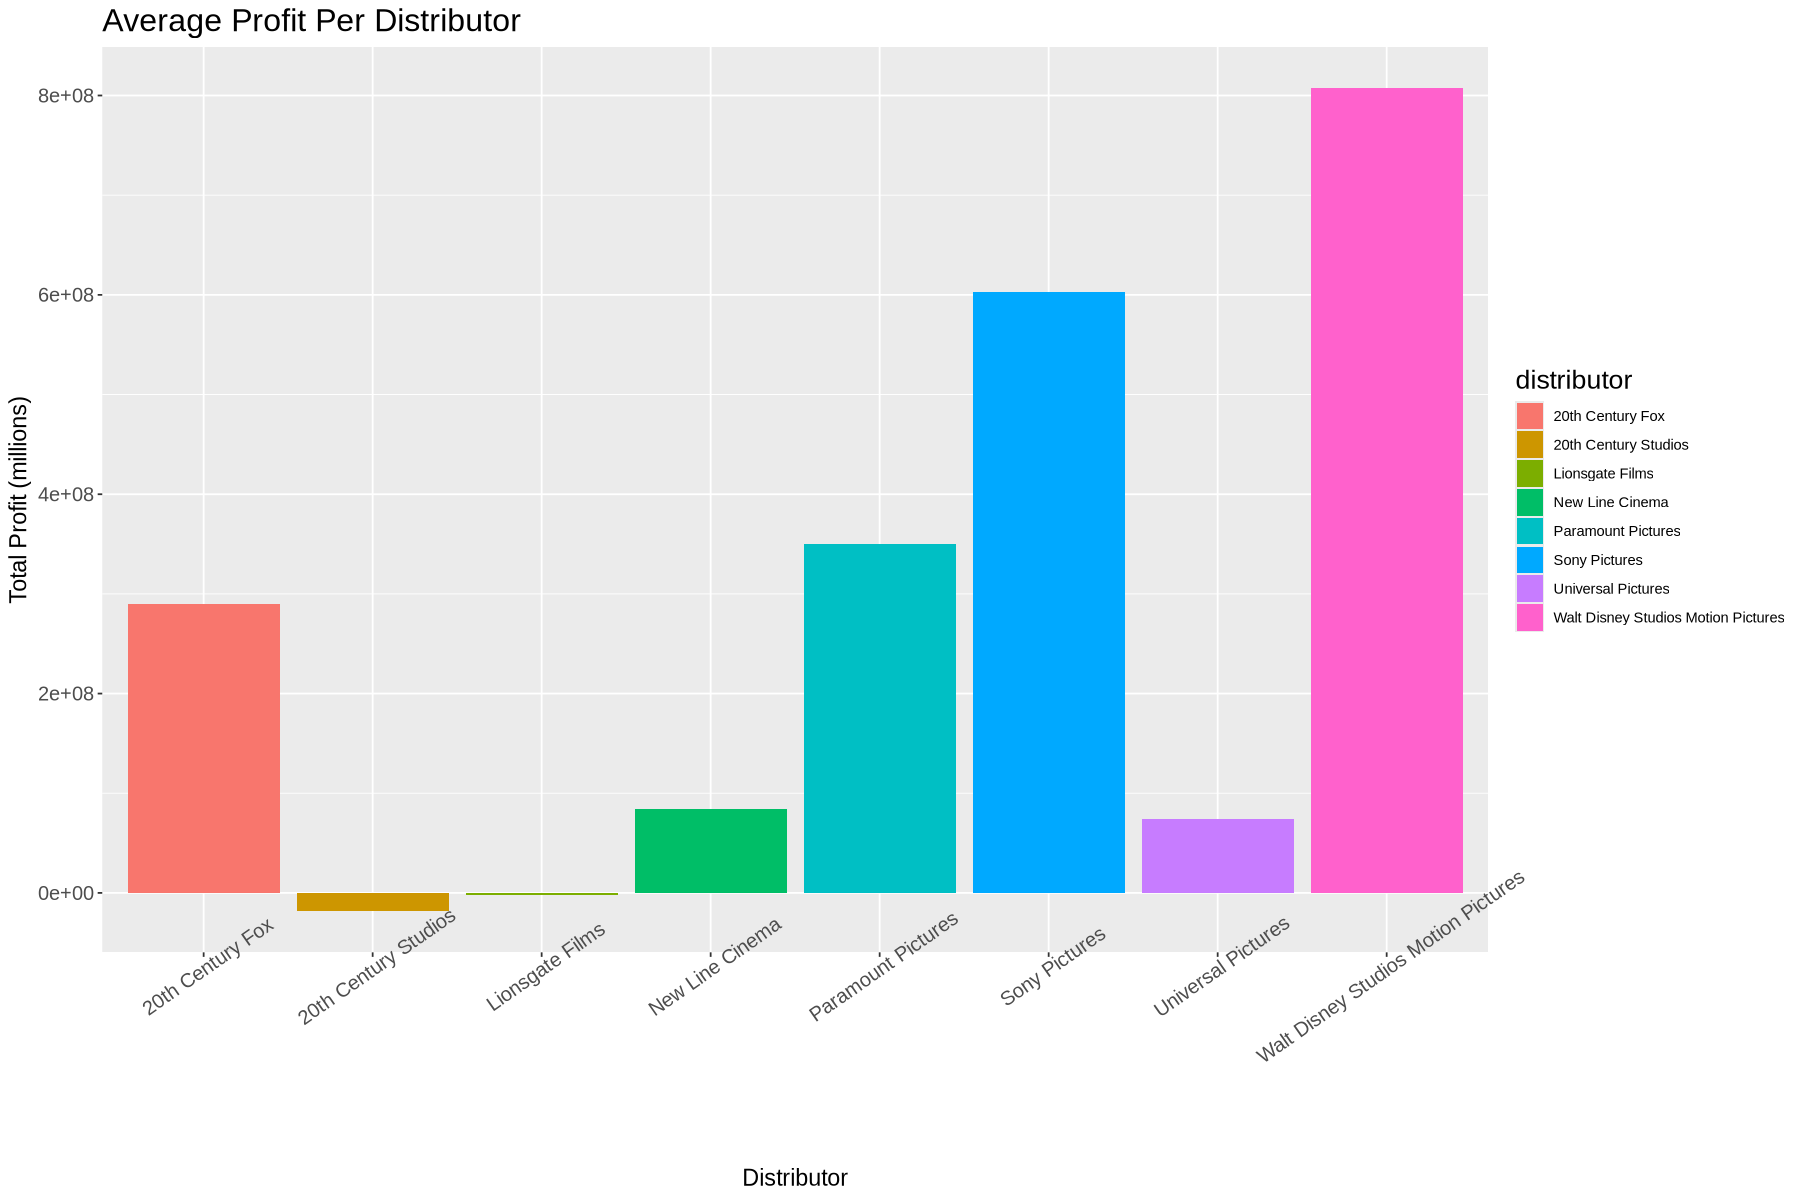

In [162]:
#average profit per distributor

distributor_profits <- movies_reviews %>% 
    group_by(distributor) %>%
    summarize(distributor_average_profit = mean(profit)) %>%
    na.omit(budget_mil) %>%
    arrange(desc(distributor_average_profit))

#bar graph
options(repr.plot.width = 15, repr.plot.height = 10)

ggplot(distributor_profits, aes(x = distributor, y = distributor_average_profit, fill = distributor)) +
    geom_bar(stat = 'identity') +
    theme(axis.text.x = element_text(angle = 35)) +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    labs(title = 'Average Profit Per Distributor', x = 'Distributor', y = 'Total Profit (millions)')


#### Distributor Anaylsis <a class='anchor' id='distributor'></a>

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


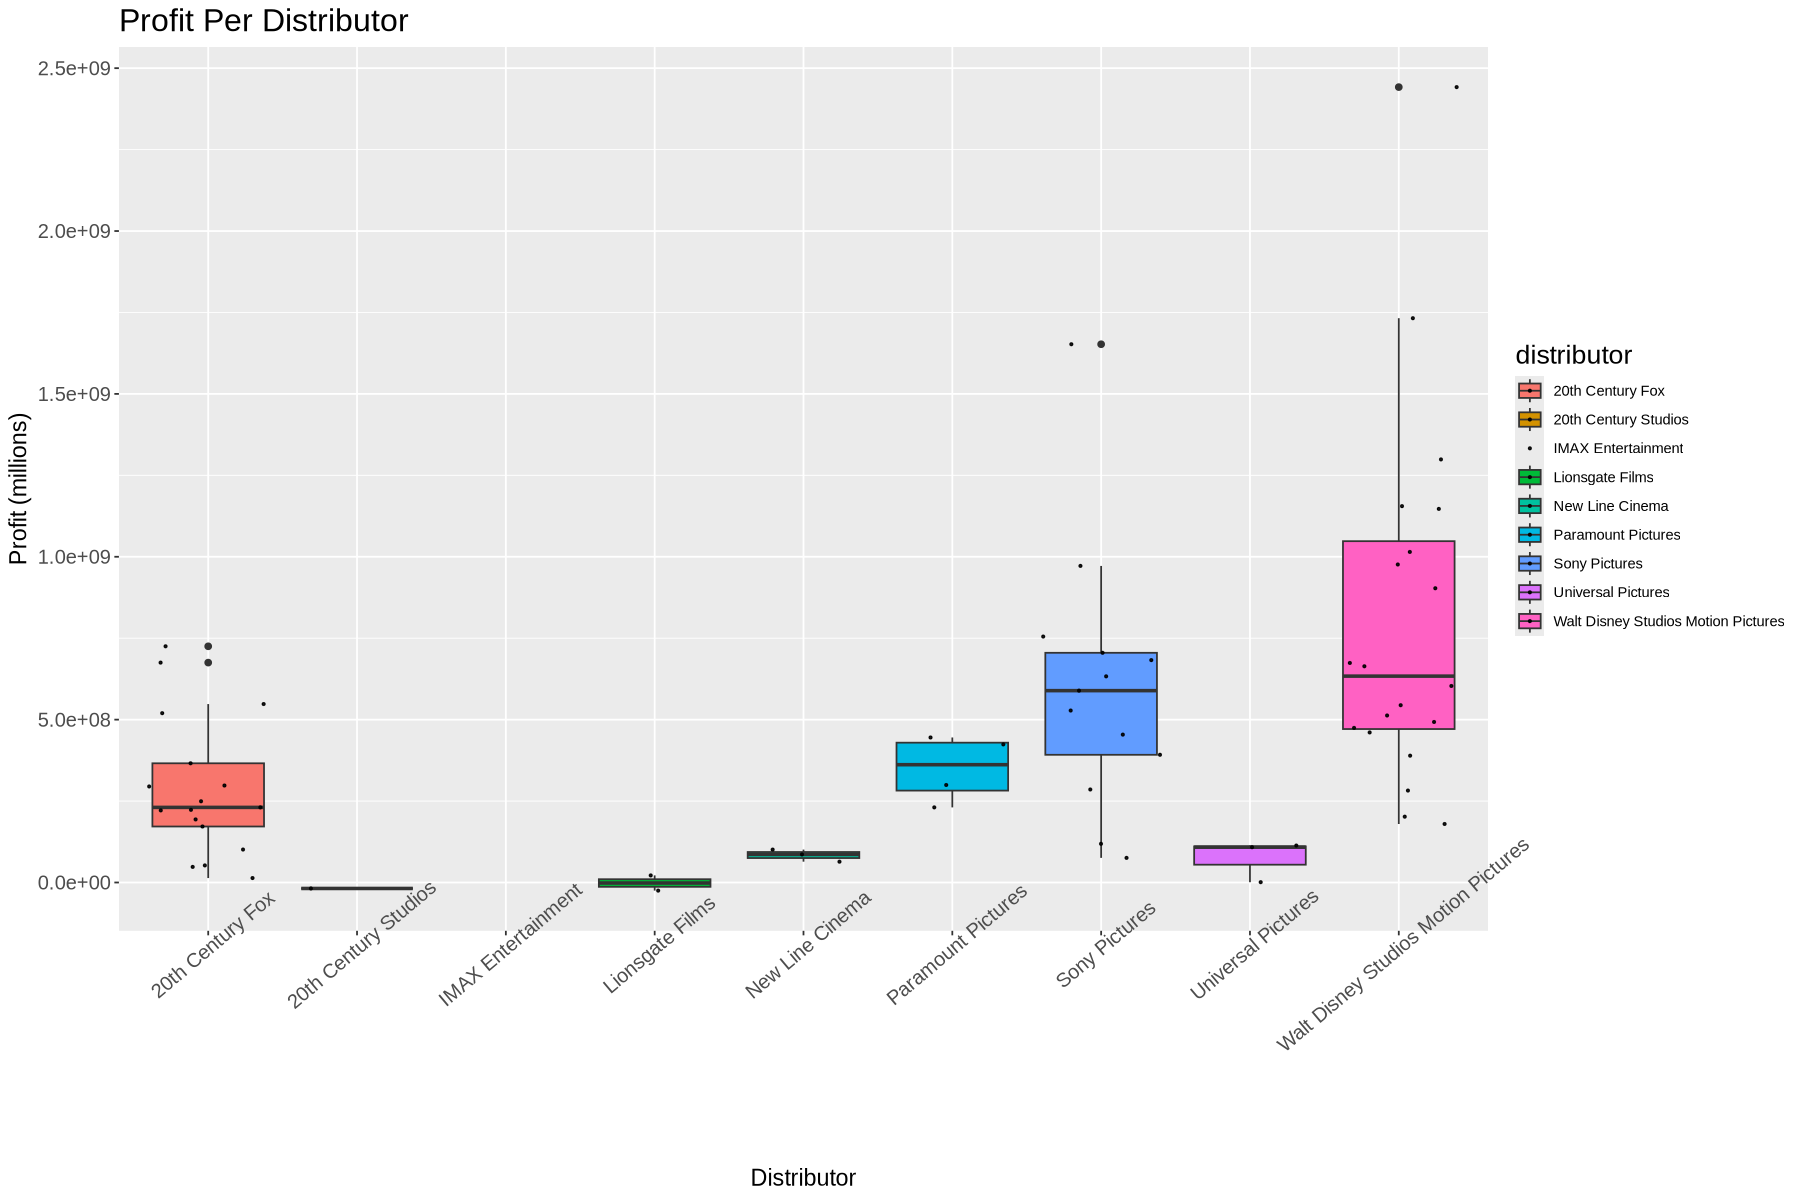

In [163]:
#distributor anaylsis

options(repr.plot.width = 15, repr.plot.height = 10)

ggplot(movies_reviews, aes(x = distributor, y= profit, fill = distributor)) +
    geom_boxplot() +
    geom_jitter(color = 'black', size = .5, alpha = .9) +
    theme(axis.text.x = element_text(angle = 40)) + 
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    labs(title = 'Profit Per Distributor', x = 'Distributor', y = 'Profit (millions)')

#### Rating Analysis <a class='anchor' id='ratings'></a>

In [164]:
#do ratings between the different platform correlate? 
no_na_reviews <- movies_reviews %>%
    na.omit(rt_percentage, metacritic_score, cinema_score) %>%
    select(title, rt_percentage, metacritic_score, cinema_score)

#convert cinema_score to estimated percentage score
no_na_reviews$cinema_score_number <- ifelse(no_na_reviews$cinema_score == 'A+', 97, 
                                        ifelse(no_na_reviews$cinema_score == 'A', 93,
                                        ifelse(no_na_reviews$cinema_score == 'A-', 90,
                                        ifelse(no_na_reviews$cinema_score == 'B+', 87,
                                        ifelse(no_na_reviews$cinema_score == 'B', 83,
                                        ifelse(no_na_reviews$cinema_score == 'B-', 80,
                                        ifelse(no_na_reviews$cinema_score == 'C+', 77,
                                        ifelse(no_na_reviews$cinema_score == 'C', 73,
                                        ifelse(no_na_reviews$cinema_score == 'C-', 70, 70)))))))))

In [165]:
#clean up no_na_reviews: 
no_na_reviews <- no_na_reviews %>%
    select(title, rt_percentage, metacritic_score, cinema_score_number)

gather_reviews <- gather(no_na_reviews, key = reviewer, value = review_scores, -title)

In [166]:
write_csv(gather_reviews, 'numeric_marvel_reviews.csv')

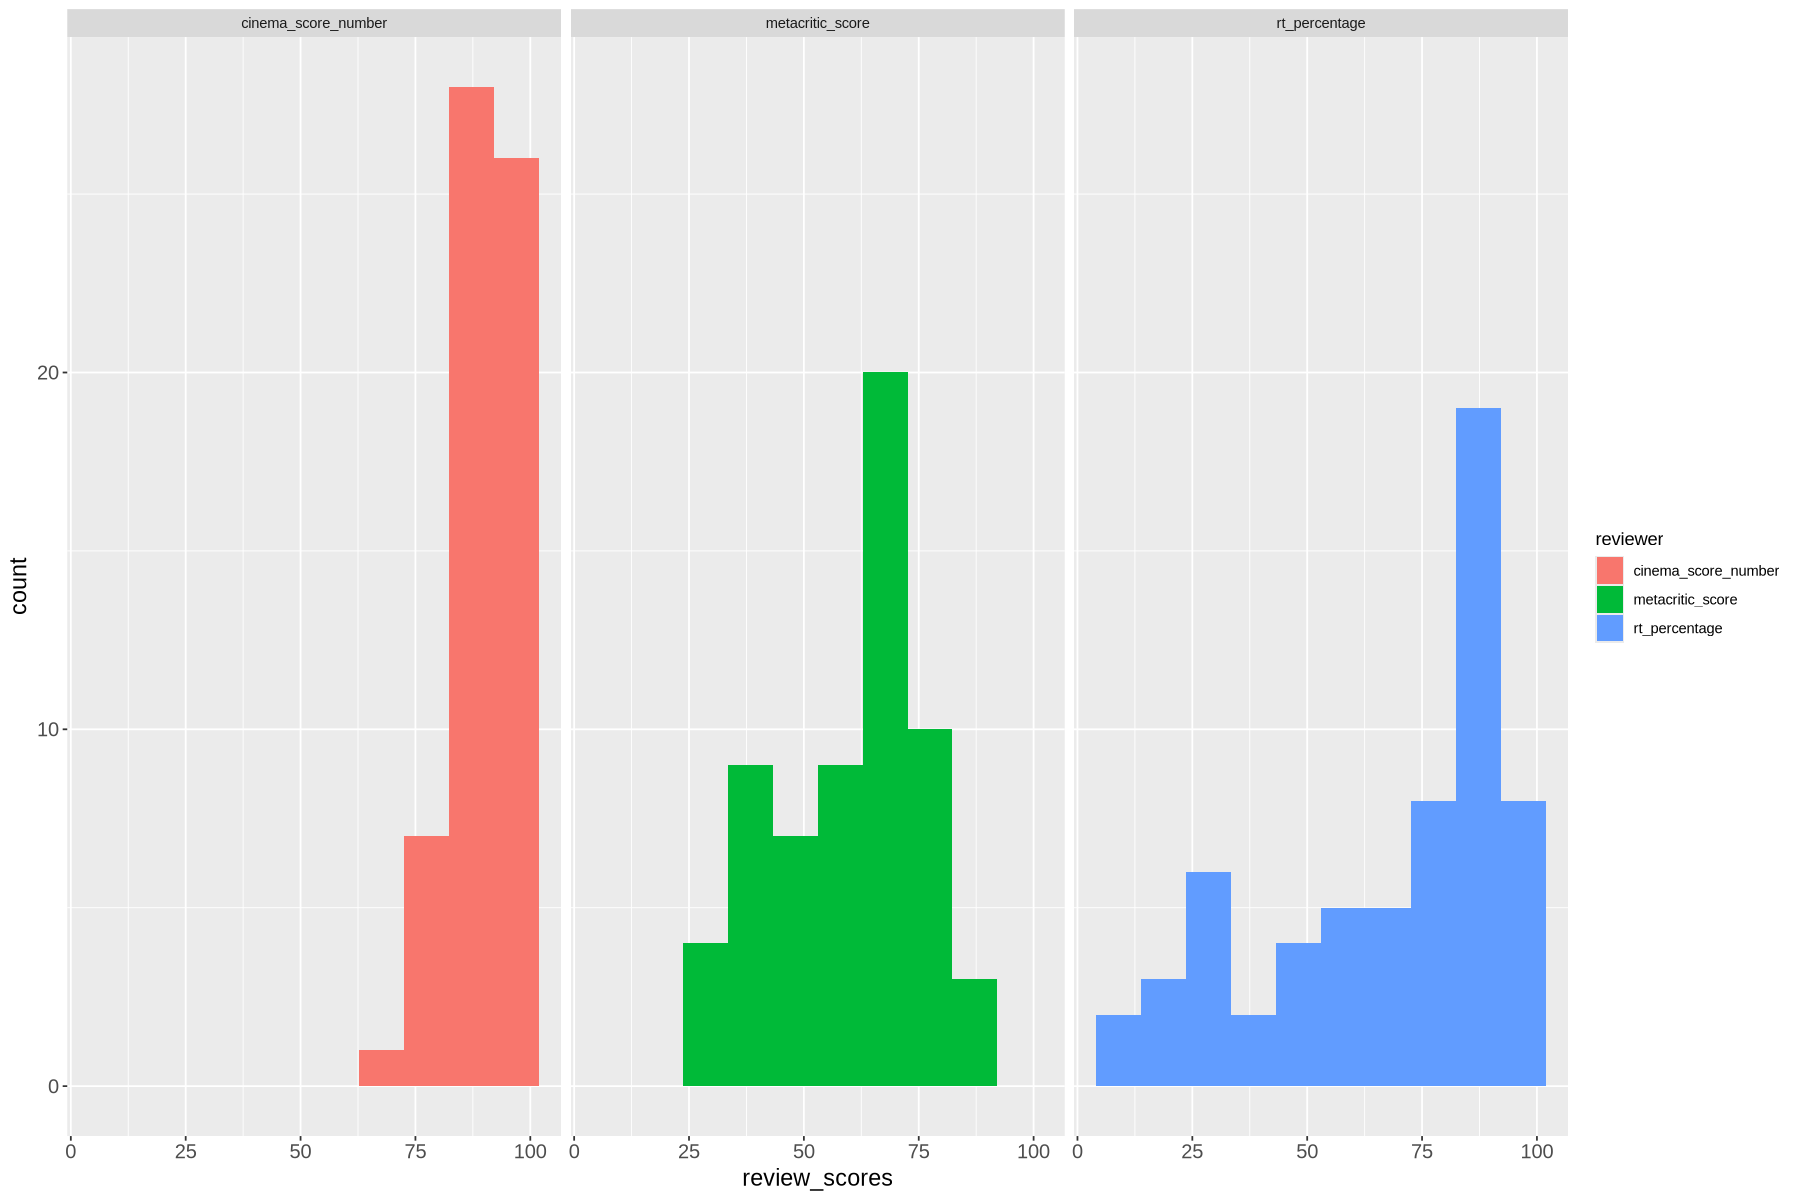

In [167]:
#view distribution of review scores per critic type
ggplot(gather_reviews, aes(review_scores, fill = reviewer)) +
       geom_histogram(bins = 10) + 
        facet_wrap(vars(reviewer)) +
        theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14))

In [168]:
#do ratings correlate with revenue (wordwide vs international vs domestic)?
#create average review rating column
gather_reviews <- gather_reviews %>%
    group_by(title) %>%
    mutate(average_review = mean(review_scores))

In [169]:
#merge gather_reviews and movies_reviews
gather_reviews <- gather_reviews %>%
    select(title, average_review)

movies_reviews <- movies_reviews %>%
    inner_join(gather_reviews)

Joining with `by = join_by(title)`


In [170]:
#remove duplicates

movies_reviews <- movies_reviews %>%
    distinct()

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'



	Pearson's product-moment correlation

data:  movies_reviews$average_review and movies_reviews$north_america
t = 6.9244, df = 60, p-value = 3.365e-09
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4999143 0.7854812
sample estimates:
      cor 
0.6664658 


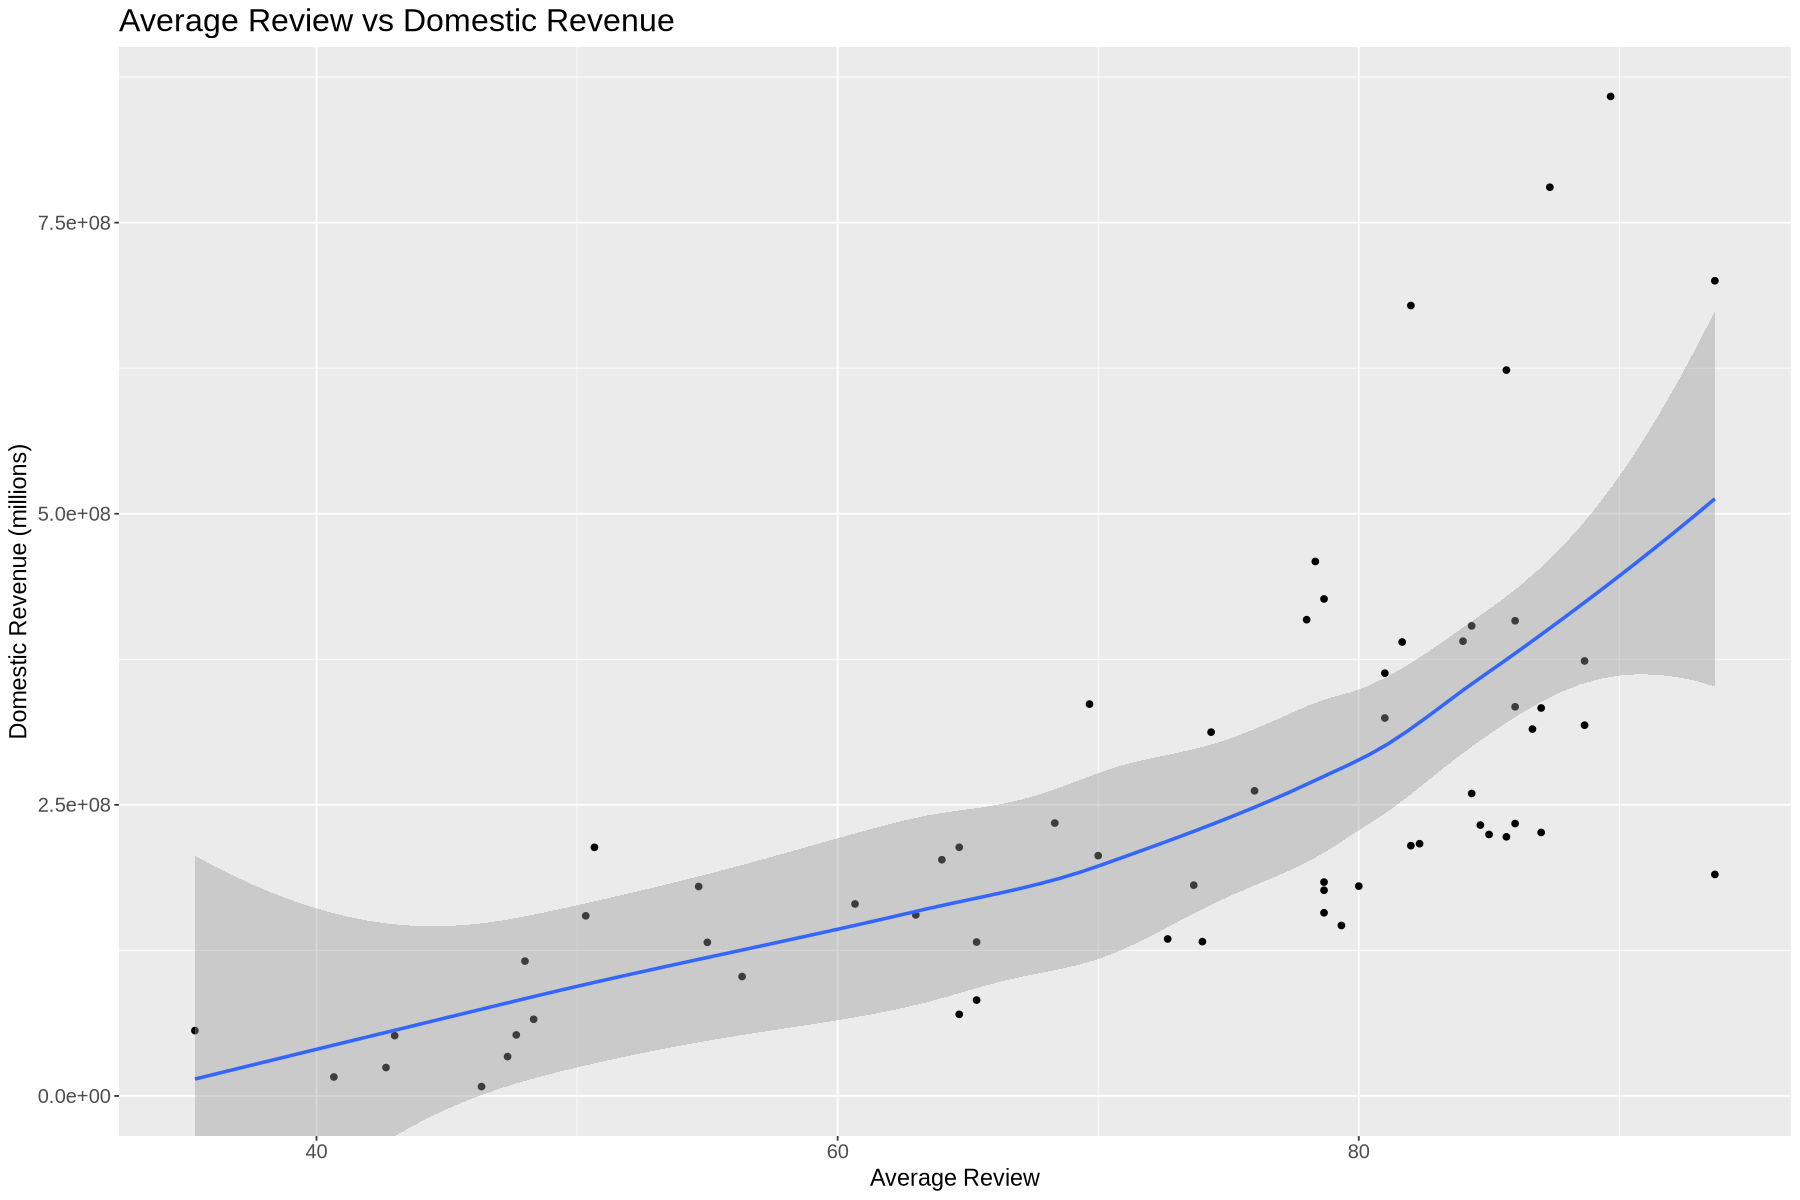

In [171]:
#plot average review vs domestic revenue
ggplot(data = movies_reviews, aes(x = average_review, y = north_america)) + 
    geom_point() +
    geom_smooth() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 14), title = element_text(size = 16)) +
    coord_cartesian(ylim = c(min(movies_reviews$north_america), max(movies_reviews$north_america))) +
    labs(title = 'Average Review vs Domestic Revenue', x = 'Average Review', y = 'Domestic Revenue (millions)')

#correlation test
cor.test(movies_reviews$average_review, movies_reviews$north_america)

In [172]:
write_csv(movies_reviews, 'marvel_movies_reviews.csv')

### Conclusion <a class='anchor' id='Conclusion'></a>

Observations: 
* Domestic opening weekend:
    * Has increased over the years for the most part with some smaller dips; large dip as a result of COVID-19 pandemic
    * Top 5 opening weekends are all based on MCU (Disney + Sony Spiderman) characters/plots
    * Majority of marvel films domestically outperform their domestic opening weekend with a few exceptions
* There is a postive correlation between budget and worldwide budget, with some outliers
* There is a postive correlation between budget and total profit, with some outliers
* Total profits for marvel movies saw a significant increase in 2012 (when the first Avengers movie was released)
* Walt Disney Studios and Sony (in association with the Disney Marvel Cinematic Universe) have the most proftiable marvel films
* From 1986 to 2021, Walt Disney Studios had the largest marvel movie profit
* Reviews:
    * Reviews based on industry critics (Rotten Tomatoes and Metacritic) have had harsher reviews of marvel movies vs audience/public reviews (CinemaScore)
    * Reviews have a postive correlation with domestic revenue

Factors that could add additional research layers/insights:
* Advertisement budget/methods
    * Number of trailors released
    * Social media/youtube vs paper/radio/TV advertisements
    * Rise of comic conventions like San Diego Comic Con
* Incorporation of home video/DVD and then streaming profits
* Marvel movies beyond COVID-19
* Marvel vs DC movies